# Google Store Thesis Revisited
## Project overview — 2021 → 2026

This notebook is the **short narrative companion** to the three executable analysis notebooks in this repository.

- `01_cleaning_eda.ipynb` — data cleaning and exploratory analysis
- `02_thesis_reproduction.ipynb` — historical model reproduction
- `03_2026_revision.ipynb` — temporal validation, leakage-free pipelines, PR-AUC, threshold tuning and early-session analysis

The project revisits my 2021 Master's thesis, originally developed in **R**, using **Python** and AI-assisted code review in 2026. The goal is not to produce a deployable e-commerce system, but to see what still holds, what breaks, and what questions I would ask differently today.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

summary = pd.DataFrame({
    "Metric": ["Sessions", "Purchases", "Purchase rate", "Years since thesis"],
    "Value": ["25,000", "323", "1.29%", ">5 years"]
})
display(summary)

,Metric,Value
0,Sessions,"25,000"
1,Purchases,323
2,Purchase rate,1.29%
3,Years since thesis,>5 years


## 1. The first conclusion still holds

With such a rare positive class, **accuracy is misleading**. On the 2026 temporal holdout, predicting *non-purchase* for every session still produces **98.46% accuracy** — with **0% sensitivity**.

## 2. Session-complete vs early-session prediction

The strongest finding from the revisit is not a new algorithm. It is a clearer definition of **when the features are available**.

`hits` and `pageviews` describe behaviour accumulated during the session. Keeping them means classifying a session with rich behavioural information; removing them makes the task closer to **early purchase prediction**.

,Model,ROC-AUC complete,PR-AUC complete,ROC-AUC early,PR-AUC early
0,Logistic Regression,0.9837,0.4035,0.7174,0.0362
1,LDA,0.9623,0.3700,0.7303,0.0360
2,SVM,0.9796,0.3728,0.7087,0.0392


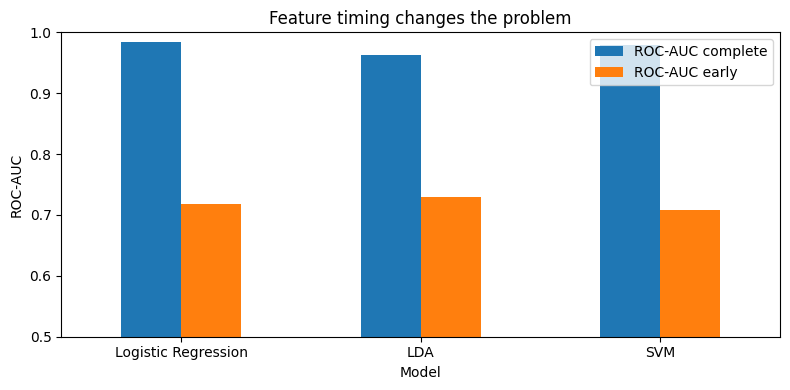

In [2]:
results = pd.DataFrame([
    ["Logistic Regression", 0.9837, 0.4035, 0.7174, 0.0362],
    ["LDA",                 0.9623, 0.3700, 0.7303, 0.0360],
    ["SVM",                 0.9796, 0.3728, 0.7087, 0.0392],
], columns=["Model", "ROC-AUC complete", "PR-AUC complete", "ROC-AUC early", "PR-AUC early"])
display(results)

ax=results.set_index("Model")[["ROC-AUC complete","ROC-AUC early"]].plot(kind="bar", figsize=(8,4), rot=0)
ax.set_ylim(0.5,1.0)
ax.set_ylabel("ROC-AUC")
ax.set_title("Feature timing changes the problem")
plt.tight_layout()
plt.show()

## 3. Qualitative variables become more valuable in the early scenario

Adding channel, source, browser, operating system and geography to the early-session Logistic Regression improves performance from:

- **ROC-AUC 0.717 → 0.875**
- **PR-AUC 0.036 → 0.167**

This reinforces one of the original thesis findings — categorical variables add signal — but gives it a more useful interpretation.

,Scenario,ROC-AUC,PR-AUC
0,Early — numeric only,0.7174,0.0362
1,Early — mixed features,0.8747,0.1671


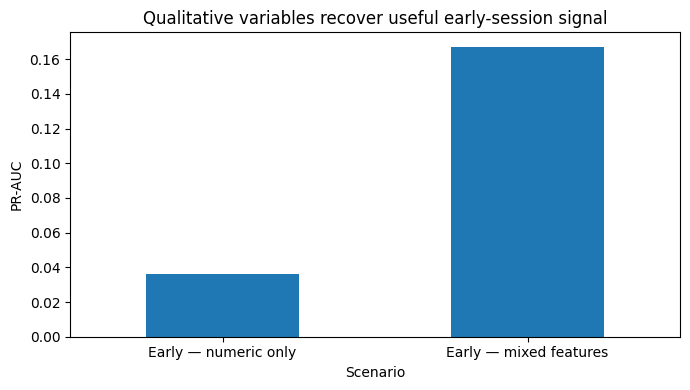

In [3]:
qual = pd.DataFrame({
    "Scenario": ["Early — numeric only", "Early — mixed features"],
    "ROC-AUC": [0.7174, 0.8747],
    "PR-AUC": [0.0362, 0.1671]
})
display(qual)

ax=qual.set_index("Scenario")[["PR-AUC"]].plot(kind="bar", figsize=(7,4), rot=0, legend=False)
ax.set_ylabel("PR-AUC")
ax.set_title("Qualitative variables recover useful early-session signal")
plt.tight_layout()
plt.show()

## 4. What changed methodologically

| Aspect | 2021 thesis | 2026 revisit |
|---|---|---|
| Language | R | Python |
| Split | Random 80/20 | Temporal holdout |
| Scaling | Before split | Fit only on training/folds |
| Balancing | Pre-generated training sets | Inside CV pipeline |
| SVM parameters | Fixed | Cross-validated |
| Evaluation | ROC + confusion metrics | PR-AUC + ROC + confusion metrics |
| Threshold | Mainly 0.5 | Tuned on training |
| Feature timing | Session-complete | Complete vs early-session |

The most important outcome was not a higher score. It was returning to the same dataset and asking **better questions**.

## 5. Where to go next

Open the numbered notebooks for the full code, figures and model outputs. The LinkedIn carousel is available in the `slides/` folder.

**R in 2021. Python + AI in 2026. Same dataset, better questions.**